In [ ]:
!pip install wordcloud matplotlib

In [ ]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

df = pd.read_csv('data_preprocessed.csv')
df = df.dropna(subset=['teks_processed', 'sentimen_auto'])

teks_positif = ' '.join(df.loc[df['sentimen_auto'] == 'positif', 'teks_processed'])
teks_negatif = ' '.join(df.loc[df['sentimen_auto'] == 'negatif', 'teks_processed'])

print('Total karakter positif:', len(teks_positif))
print('Total karakter negatif:', len(teks_negatif))

Total karakter positif: 206838
Total karakter negatif: 33254


**WordCloud Positif**

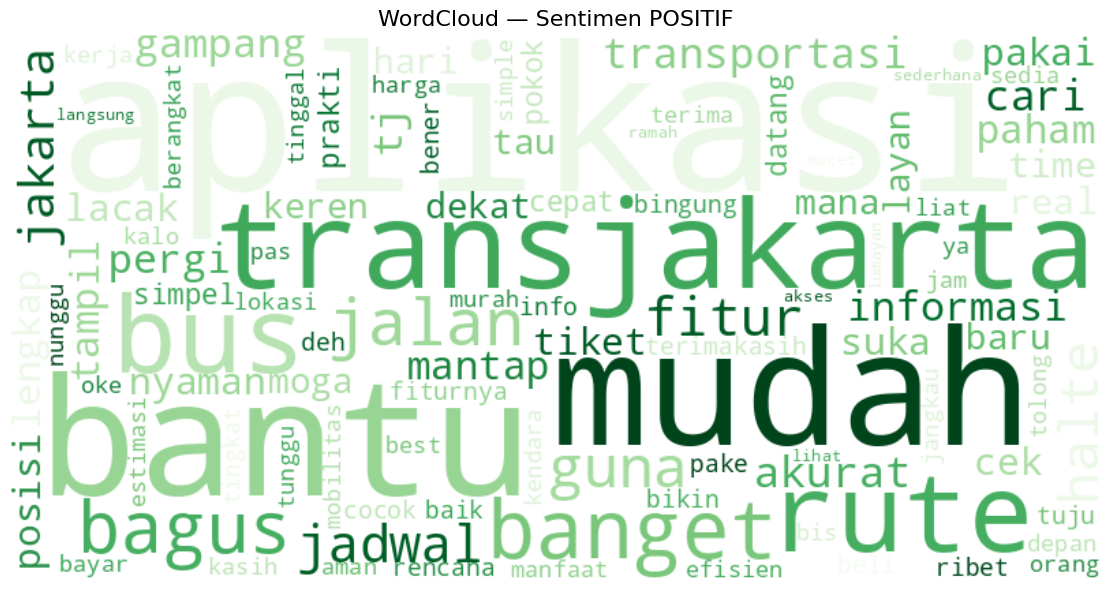

In [ ]:
wc_pos = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Greens',
    max_words=100,
    collocations=False
).generate(teks_positif)

plt.figure(figsize=(12, 6))
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud — Sentimen POSITIF', fontsize=16)
plt.tight_layout()
plt.savefig('wordcloud_positif.png', dpi=150, bbox_inches='tight')
plt.show()

**WordCloud Negatif**

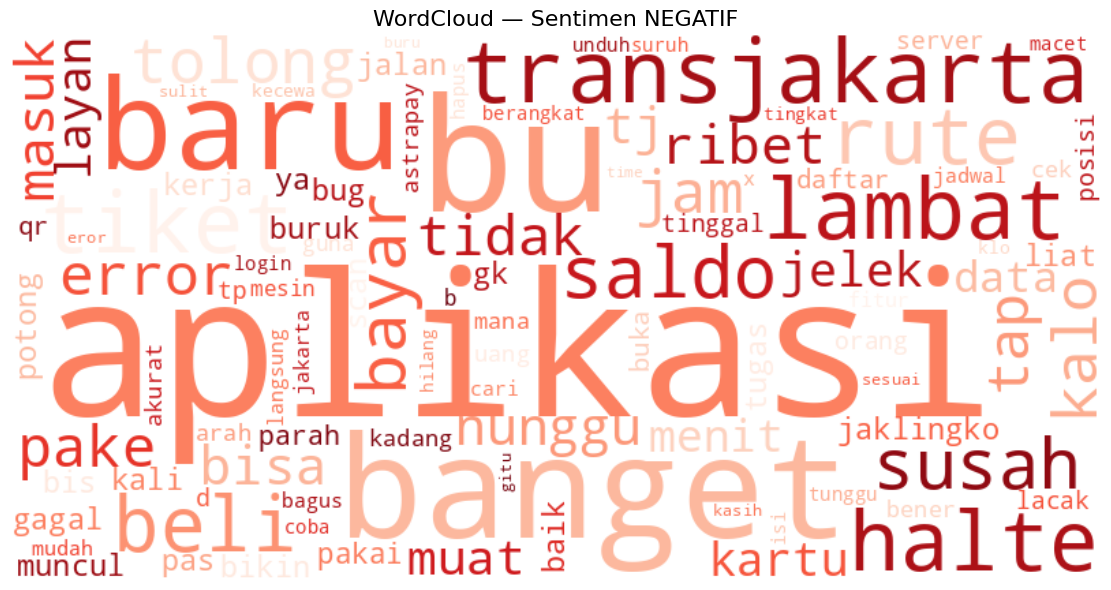

In [ ]:
wc_neg = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Reds',
    max_words=100,
    collocations=False
).generate(teks_negatif)

plt.figure(figsize=(12, 6))
plt.imshow(wc_neg, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud — Sentimen NEGATIF', fontsize=16)
plt.tight_layout()
plt.savefig('wordcloud_negatif.png', dpi=150, bbox_inches='tight')
plt.show()

**Tabel**

In [ ]:
from collections import Counter

def top_words(teks, n=10):
    kata = teks.split()
    return Counter(kata).most_common(n)

top_pos = top_words(teks_positif, 10)
top_neg = top_words(teks_negatif, 10)

print('Top 10 kata POSITIF:')
for k, v in top_pos:
    print(f'  {k:15s} : {v}')

print('\nTop 10 kata NEGATIF:')
for k, v in top_neg:
    print(f'  {k:15s} : {v}')

Top 10 kata POSITIF:
  aplikasi        : 2398
  bantu           : 1509
  mudah           : 1423
  transjakarta    : 1242
  rute            : 956
  bus             : 916
  banget          : 887
  bagus           : 670
  jalan           : 576
  guna            : 466

Top 10 kata NEGATIF:
  aplikasi        : 204
  bus             : 118
  banget          : 96
  baru            : 73
  transjakarta    : 72
  lambat          : 67
  tiket           : 67
  halte           : 64
  rute            : 57
  beli            : 54


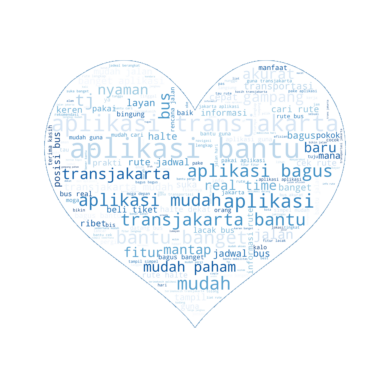

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# 1. Load gambar mask
mask = np.array(Image.open('heart_logo.jpg'))

# 2. Generate WordCloud
wc = WordCloud(background_color='white', mask=mask,
               colormap='Blues', contour_color='steelblue',
               contour_width=2).generate(teks_positif)

# 3. Plot menggunakan Matplotlib
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')

# =========================================================================
# TAMBAHKAN KODE DI BAWAH INI UNTUK DOWNLOAD/SAVE GAMBAR
# =========================================================================

# Cara 1: Menyimpan hasil plot matplotlib (Sangat direkomendasikan karena ikut menyimpan kontur/garis tepi)
plt.savefig('wordcloud_positif.png', bbox_inches='tight', dpi=300)

# Cara 2: Atau bisa juga menyimpan gambar wordcloud mentah murni tanpa dekorasi matplotlib
# wc.to_file('wordcloud_positif_raw.png')